In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [2]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
df.describe()

Shape: (918, 12)

Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Data Types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Statistical Summary:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


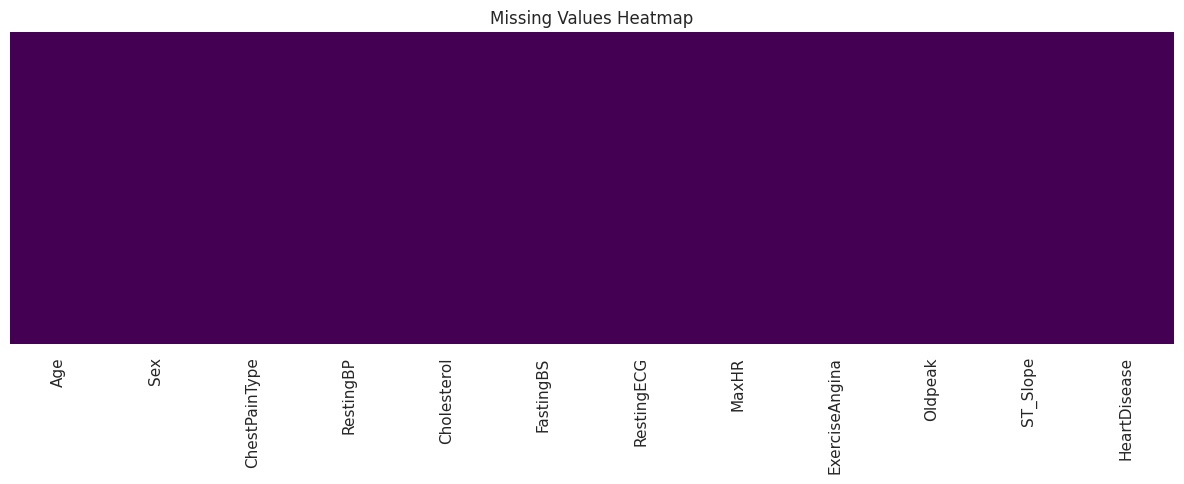

In [3]:
print("Missing Values:")
print(df.isnull().sum())

plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

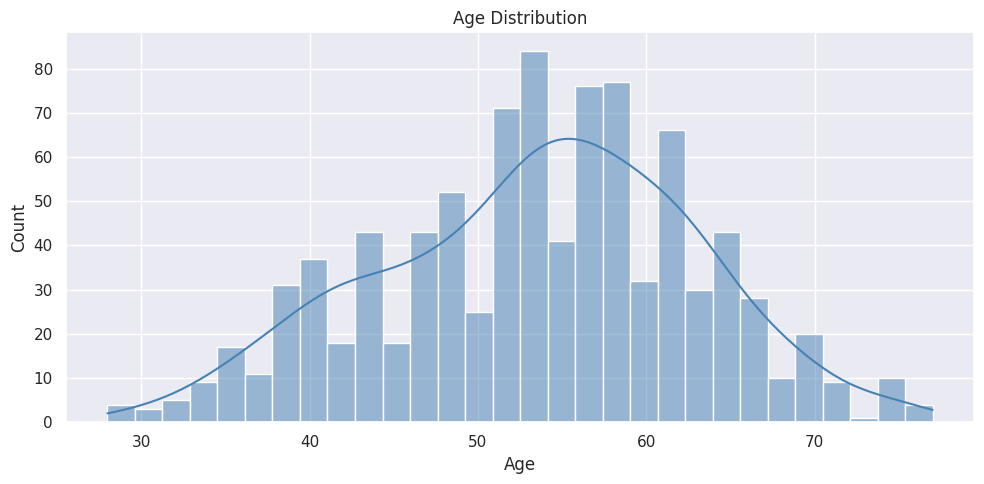

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='steelblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

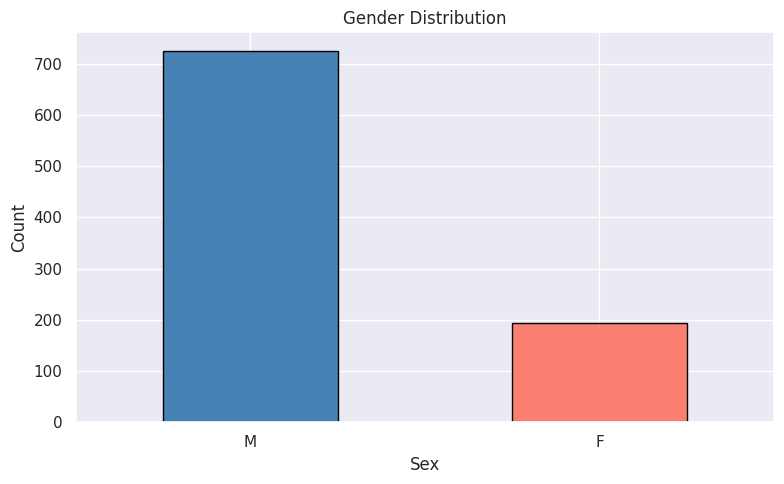

In [5]:
plt.figure(figsize=(8, 5))
df['Sex'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

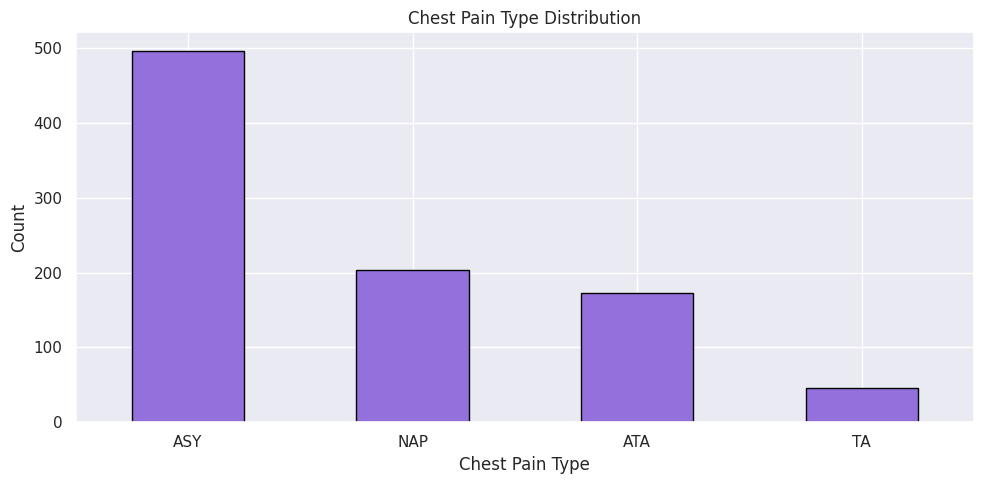

In [6]:
plt.figure(figsize=(10, 5))
df['ChestPainType'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title("Chest Pain Type Distribution")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

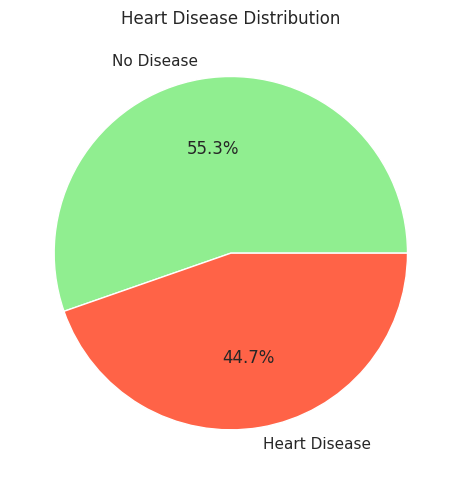

In [7]:
plt.figure(figsize=(8, 5))
df['HeartDisease'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                        colors=['lightgreen', 'tomato'],
                                        labels=['No Disease', 'Heart Disease'])
plt.title("Heart Disease Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

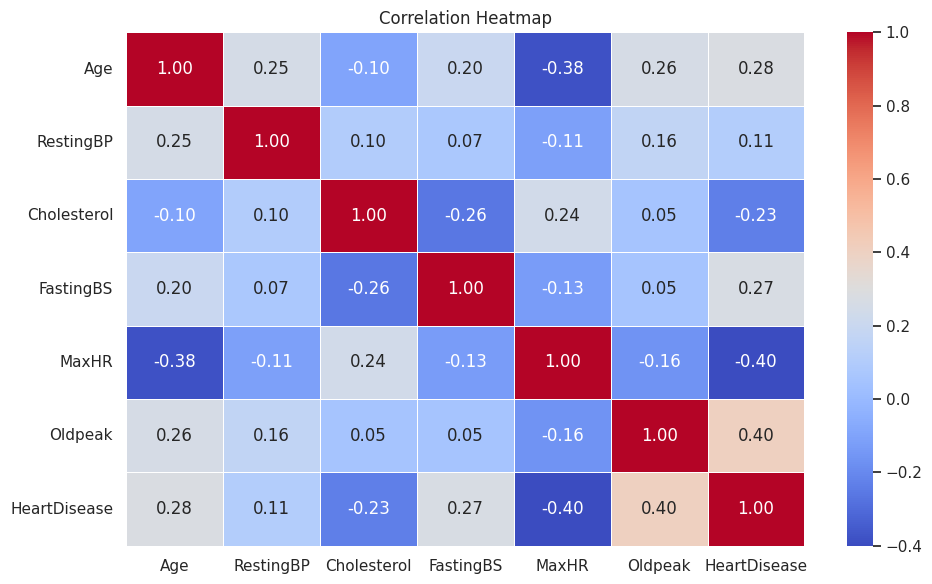

In [8]:
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=np.number)
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

/tmp/ipykernel_504/3183508034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='Age', data=df, palette='Set2')


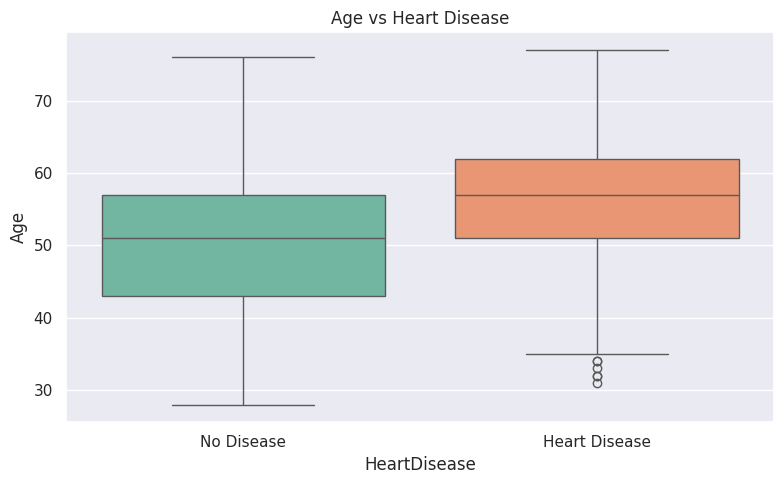

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='HeartDisease', y='Age', data=df, palette='Set2')
plt.title("Age vs Heart Disease")
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

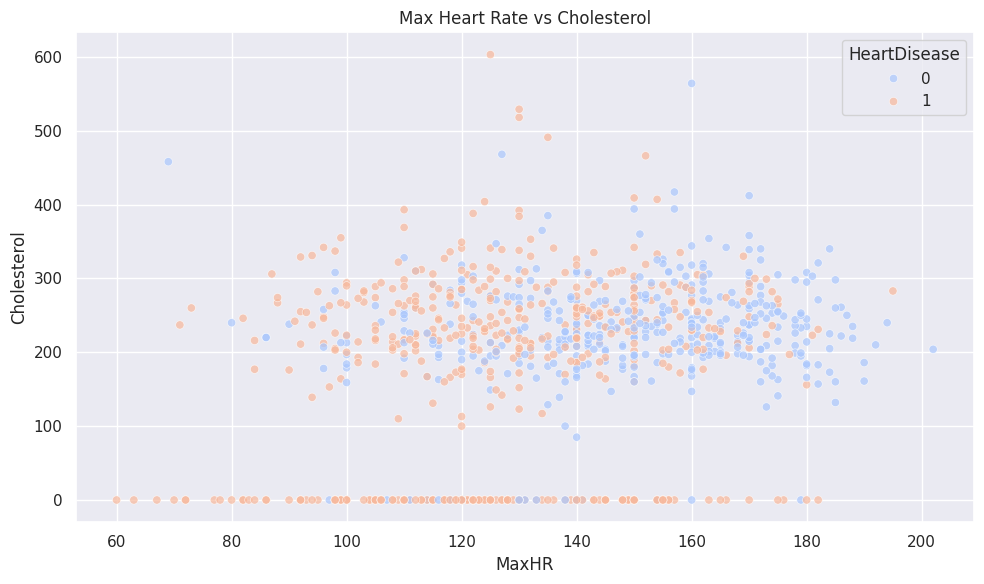

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MaxHR', y='Cholesterol', hue='HeartDisease',
                data=df, palette='coolwarm', alpha=0.7)
plt.title("Max Heart Rate vs Cholesterol")
plt.tight_layout()
plt.show()

/tmp/ipykernel_504/1557863531.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HeartDisease', y='RestingBP', data=df, palette='Oranges')


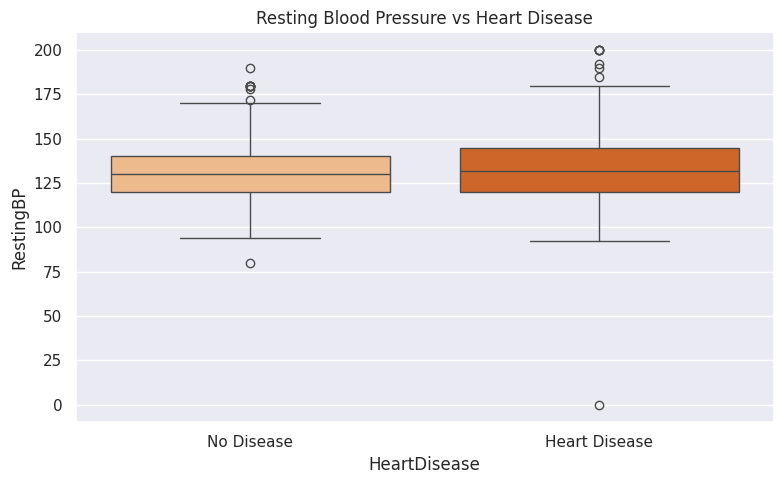

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='HeartDisease', y='RestingBP', data=df, palette='Oranges')
plt.title("Resting Blood Pressure vs Heart Disease")
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

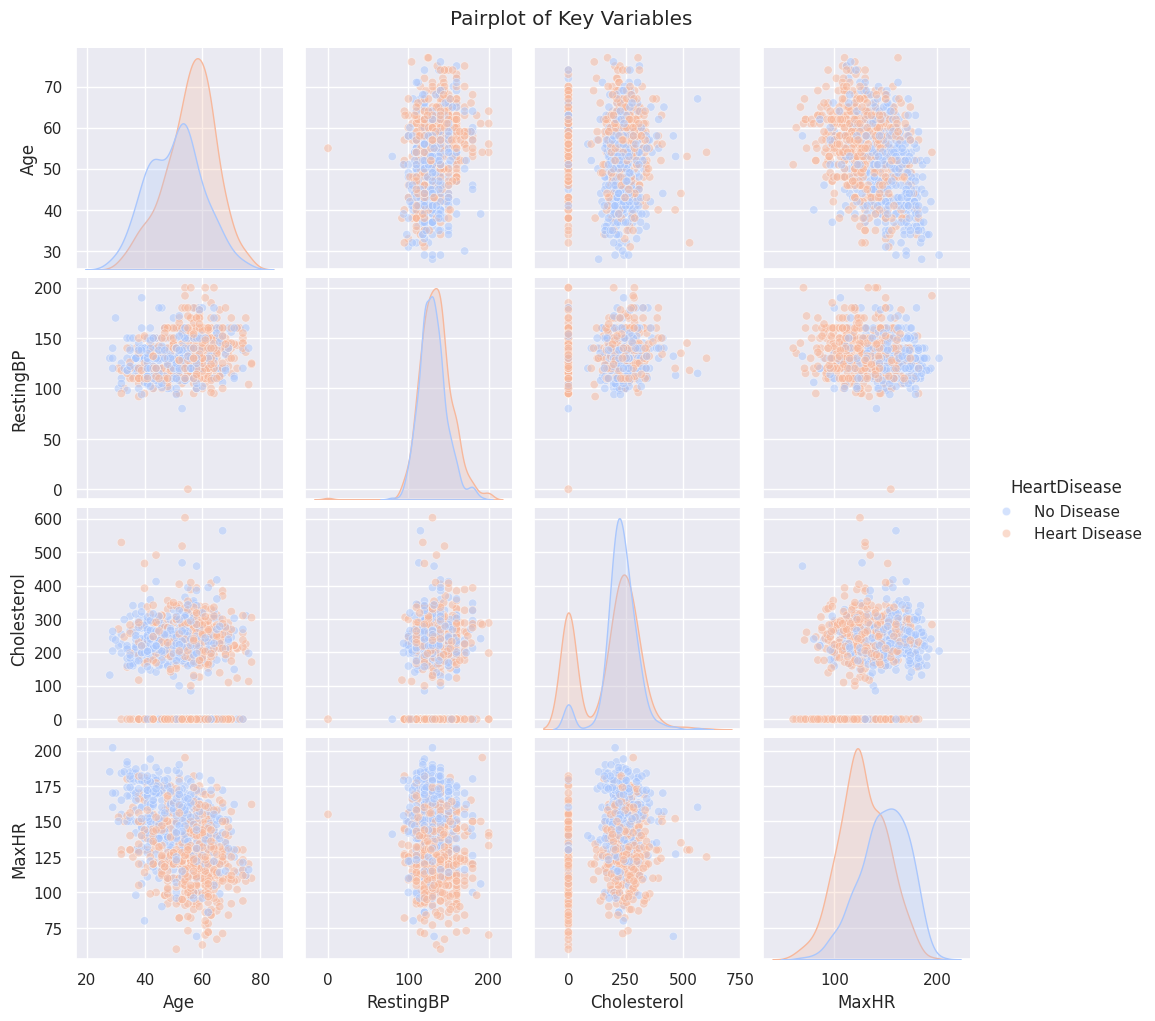

In [12]:
sample = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'HeartDisease']].copy()
sample['HeartDisease'] = sample['HeartDisease'].map({0: 'No Disease', 1: 'Heart Disease'})

sns.pairplot(sample, hue='HeartDisease', plot_kws={'alpha': 0.5}, palette='coolwarm')
plt.suptitle("Pairplot of Key Variables", y=1.02)
plt.show()

In [13]:
print("=" * 50)
print("EDA Summary - Heart Disease Dataset")
print("=" * 50)
print(f"Total Records      : {df.shape[0]:,}")
print(f"Total Features     : {df.shape[1]}")
print(f"Missing Values     : {df.isnull().sum().sum()}")
print(f"Avg Age            : {df['Age'].mean():.1f} years")
print(f"Avg Resting BP     : {df['RestingBP'].mean():.1f}")
print(f"Avg Cholesterol    : {df['Cholesterol'].mean():.1f}")
print(f"Avg Max Heart Rate : {df['MaxHR'].mean():.1f}")
print(f"Heart Disease %    : {df['HeartDisease'].mean()*100:.1f}%")

EDA Summary - Heart Disease Dataset
Total Records      : 918
Total Features     : 12
Missing Values     : 0
Avg Age            : 53.5 years
Avg Resting BP     : 132.4
Avg Cholesterol    : 198.8
Avg Max Heart Rate : 136.8
Heart Disease %    : 55.3%
